Import the libraries.

In [92]:
import numpy as np
import pandas as pd

Read the dataset.

In [93]:
df_new = pd.read_csv('Datasets/Iris.csv')
df = df_new.drop('Id', axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Label encode the species column.

In [94]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [95]:
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]
df.head(), df.shape

(    SepalWidthCm  PetalLengthCm  Species
 50           3.2            4.7        1
 51           3.2            4.5        1
 52           3.1            4.9        1
 53           2.3            4.0        1
 54           2.8            4.6        1,
 (100, 3))

Plot the data.

<Axes: xlabel='SepalWidthCm', ylabel='PetalLengthCm'>

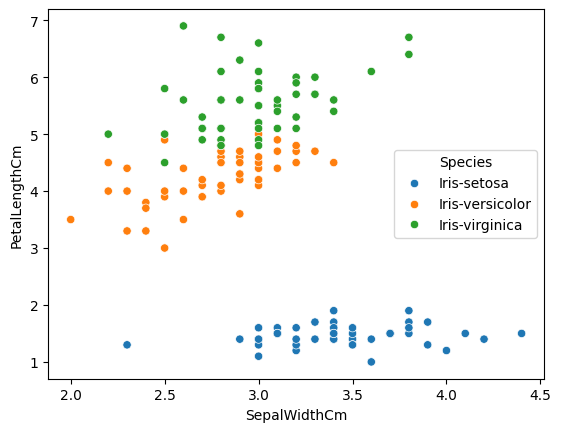

In [96]:
import seaborn as sns
sns.scatterplot(data=df_new, x='SepalWidthCm', y='PetalLengthCm', hue='Species')

In [97]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
101,2.7,5.1,2
99,2.8,4.1,1
72,2.5,4.9,1
91,3.0,4.6,1
57,2.4,3.3,1
87,2.3,4.4,1
53,2.3,4.0,1
60,2.0,3.5,1
55,2.8,4.5,1
106,2.5,4.5,2


In [98]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)
df_train

,SepalWidthCm,PetalLengthCm,Species
142,2.7,5.1,2
67,2.7,4.1,1
75,3.0,4.4,1
139,3.1,5.4,2
66,3.0,4.5,1
88,3.0,4.1,1
124,3.3,5.7,2
93,2.3,3.3,1
129,3.0,5.8,2
122,2.8,6.7,2


In [99]:
df_val

,SepalWidthCm,PetalLengthCm,Species
58,2.9,4.6,1
92,2.6,4.0,1
120,3.2,5.7,2
63,2.9,4.7,1
61,3.0,4.2,1


In [100]:
df_test

,SepalWidthCm,PetalLengthCm,Species
118,2.6,6.9,2
79,2.6,3.5,1
127,3.0,4.9,2
138,3.0,4.8,2
109,3.6,6.1,2


In [101]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values
y_test

array([1, 1, 2, 1, 1])

Bagging - we do sampling with replacement

In [102]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
129,3.0,5.8,2
67,2.7,4.1,1
142,2.7,5.1,2
88,3.0,4.1,1
142,2.7,5.1,2
122,2.8,6.7,2
122,2.8,6.7,2
139,3.1,5.4,2


Accuracy: 0.8


/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<Figure size 1000x600 with 0 Axes>

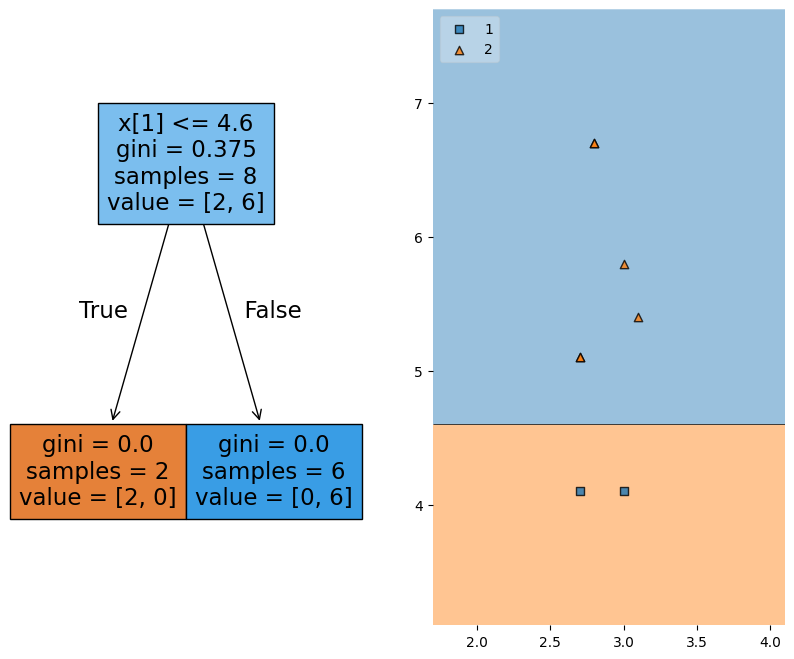

In [103]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def evaluate(model, X, y):
    model.fit(X, y)
    plt.figure(figsize=(10,6))
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,8))
    plot_tree(model, filled=True, ax=ax1)
    plot_decision_regions(X.values, y.values, clf=model, legend=2, ax=ax2)
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1,X,y)

Accuracy: 1.0


/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<Figure size 1000x600 with 0 Axes>

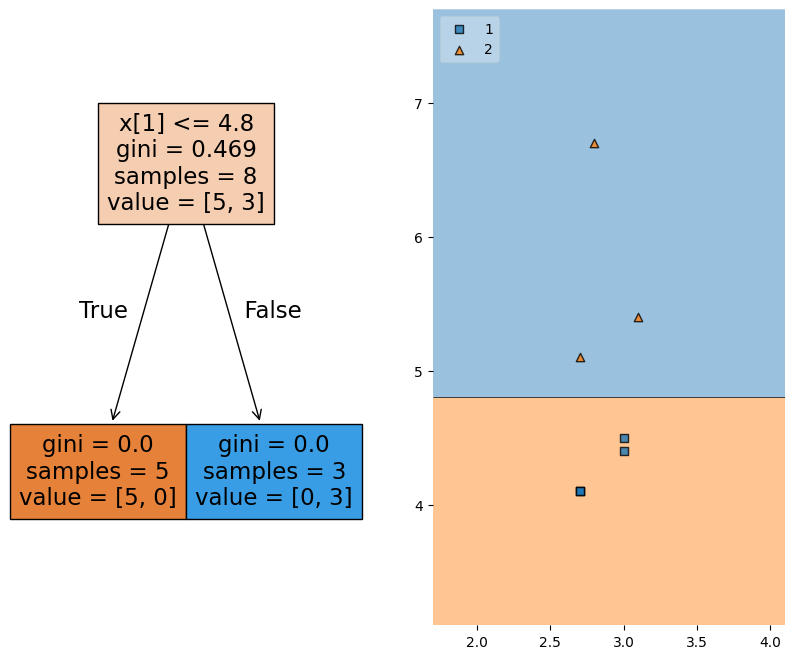

In [104]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

Accuracy: 0.8


/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<Figure size 1000x600 with 0 Axes>

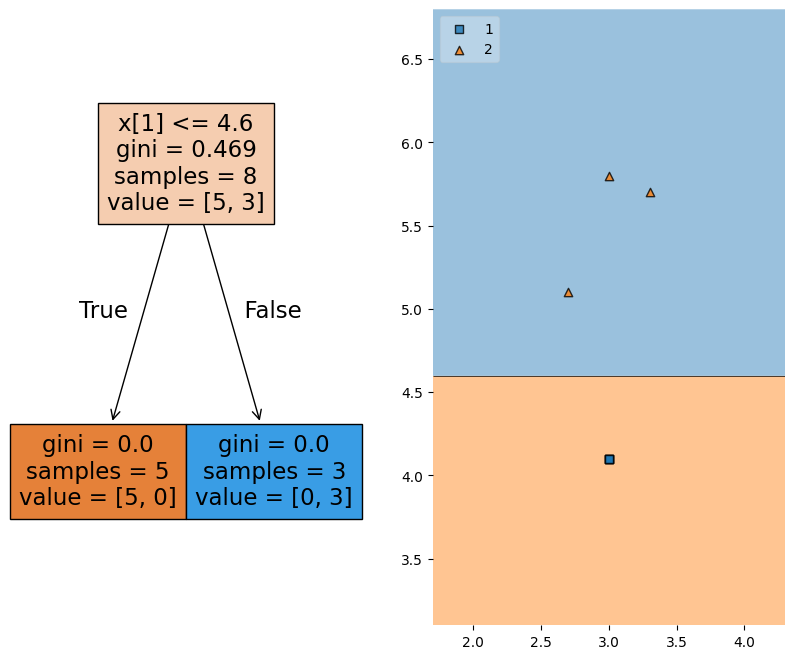

In [105]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

Predict

In [106]:
df_test

,SepalWidthCm,PetalLengthCm,Species
118,2.6,6.9,2
79,2.6,3.5,1
127,3.0,4.9,2
138,3.0,4.8,2
109,3.6,6.1,2


In [107]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Pasting - sampling without replacement.

In [109]:
df_train

,SepalWidthCm,PetalLengthCm,Species
142,2.7,5.1,2
67,2.7,4.1,1
75,3.0,4.4,1
139,3.1,5.4,2
66,3.0,4.5,1
88,3.0,4.1,1
124,3.3,5.7,2
93,2.3,3.3,1
129,3.0,5.8,2
122,2.8,6.7,2


In [110]:
df_train.sample(8,replace=False)

,SepalWidthCm,PetalLengthCm,Species
93,2.3,3.3,1
75,3.0,4.4,1
139,3.1,5.4,2
142,2.7,5.1,2
122,2.8,6.7,2
66,3.0,4.5,1
67,2.7,4.1,1
124,3.3,5.7,2


Random Subspacing - column sampling with or wihtout sampling.

In [113]:
df.sample(4,replace=True,axis=1)

,Species,SepalWidthCm,PetalLengthCm,SepalWidthCm
142,2,2.7,5.1,2.7
135,2,3.0,6.1,3.0
64,1,2.9,3.6,2.9
94,1,2.7,4.2,2.7
124,2,3.3,5.7,3.3
...,...,...,...,...
57,1,2.4,3.3,2.4
89,1,2.5,4.0,2.5
114,2,2.8,5.1,2.8
118,2,2.6,6.9,2.6


Random patching - row + column sampling.

In [115]:
df.sample(8,replace=True).sample(4,replace=True,axis=1)

,SepalWidthCm,SepalWidthCm,SepalWidthCm,Species
59,2.7,2.7,2.7,1
102,3.0,3.0,3.0,2
75,3.0,3.0,3.0,1
102,3.0,3.0,3.0,2
130,2.8,2.8,2.8,2
54,2.8,2.8,2.8,1
87,2.3,2.3,2.3,1
142,2.7,2.7,2.7,2
